# Short-Time Variational Mode Decomposition (STVMD)

This notebook reproduces the main synthetic experiments from:

> Jia, H. et al. *Short-time variational mode decomposition*, Signal Processing, 238:110203, 2026.

STVMD extends VMD by applying a short-time Fourier transform (STFT) and solving the variational problem on overlapping frames. Two variants are available:

- **Non-dynamic STVMD**: shared centre frequencies across time
- **Dynamic STVMD**: centre frequencies that vary with time (better for non-stationary signals)


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import STVMD, VMD

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## 1. Stationary two-tone mixture

Reproduces the paper's basic example: a sum of 20 Hz and 28 Hz tones.


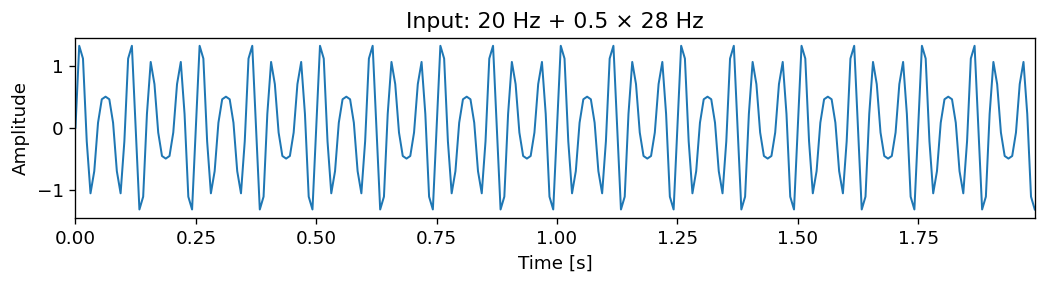

In [ ]:
N = 256
fs = 128.0
t = np.arange(N) / fs
x1 = np.sin(2 * np.pi * 20 * t)
x2 = 0.5 * np.sin(2 * np.pi * 28 * t)
signal = x1 + x2

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.plot(t, signal, color="C0", lw=1.2)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Input: 20 Hz + 0.5 × 28 Hz")
ax.set_xlim(t[0], t[-1])
plt.tight_layout()
plt.show()

### Classical VMD vs non-dynamic / dynamic STVMD


In [ ]:
K = 3
alpha = 50.0
n_fft = 64

vmd = VMD(K=K, alpha=alpha, tau=1e-5, tol=1e-9, max_iter=500)
imf_vmd = vmd.fit_transform(signal)

stvmd_nd = STVMD(
    K=K,
    alpha=alpha,
    n_fft=n_fft,
    tau=1e-5,
    tol=1e-9,
    max_iter=500,
    dynamic=False,
    window="hamming",
)
imf_nd, _, omega_nd = stvmd_nd.fit_transform(signal, return_all=True)

stvmd_d = STVMD(
    K=K,
    alpha=alpha,
    n_fft=n_fft,
    tau=1e-5,
    tol=1e-9,
    max_iter=500,
    dynamic=True,
    window="hamming",
)
imf_d, _, omega_d = stvmd_d.fit_transform(signal, return_all=True)

print("Non-dynamic centre frequencies (normalized):", np.round(omega_nd, 4))
print("Dynamic omega shape:", omega_d.shape)

Non-dynamic centre frequencies (normalized): [0.     0.3314 0.4557]
Dynamic omega shape: (3, 256)


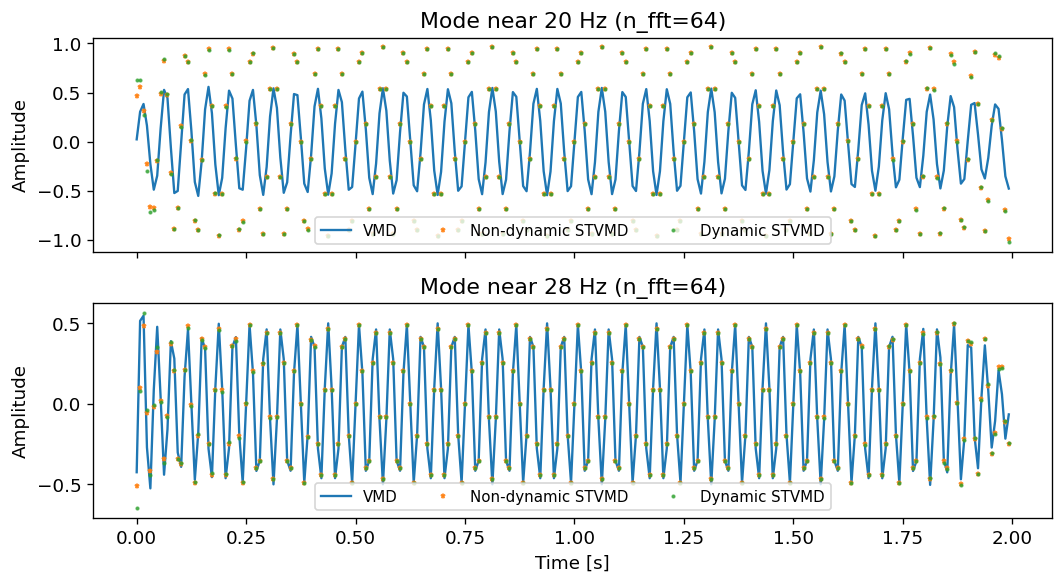

In [ ]:
freqs_hz = [20, 28]
fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for j, f0 in enumerate(freqs_hz):
    # Mode index j+1 skips the near-DC residual (mode 0)
    axs[j].plot(t, imf_vmd[j + 1], "-", label="VMD", lw=1.4)
    axs[j].plot(t, imf_nd[j + 1], "*", label="Non-dynamic STVMD", ms=3, alpha=0.8)
    axs[j].plot(t, imf_d[j + 1], ".", label="Dynamic STVMD", ms=3, alpha=0.7)
    axs[j].set_ylabel("Amplitude")
    axs[j].set_title(f"Mode near {f0} Hz (n_fft={n_fft})")
    axs[j].legend(loc="lower center", ncol=3, fontsize=9)
axs[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

In [5]:
recon_nd = imf_nd.sum(axis=0)
recon_d = imf_d.sum(axis=0)
re_nd = np.linalg.norm(recon_nd - signal) / np.linalg.norm(signal)
re_d = np.linalg.norm(recon_d - signal) / np.linalg.norm(signal)
print(f"Relative reconstruction error | non-dynamic: {re_nd:.4e}")
print(f"Relative reconstruction error | dynamic:     {re_d:.4e}")

Relative reconstruction error | non-dynamic: 4.5194e-02
Relative reconstruction error | dynamic:     4.2728e-02


### Effect of window length `n_fft`

Non-dynamic STVMD approaches classical VMD as the window grows.


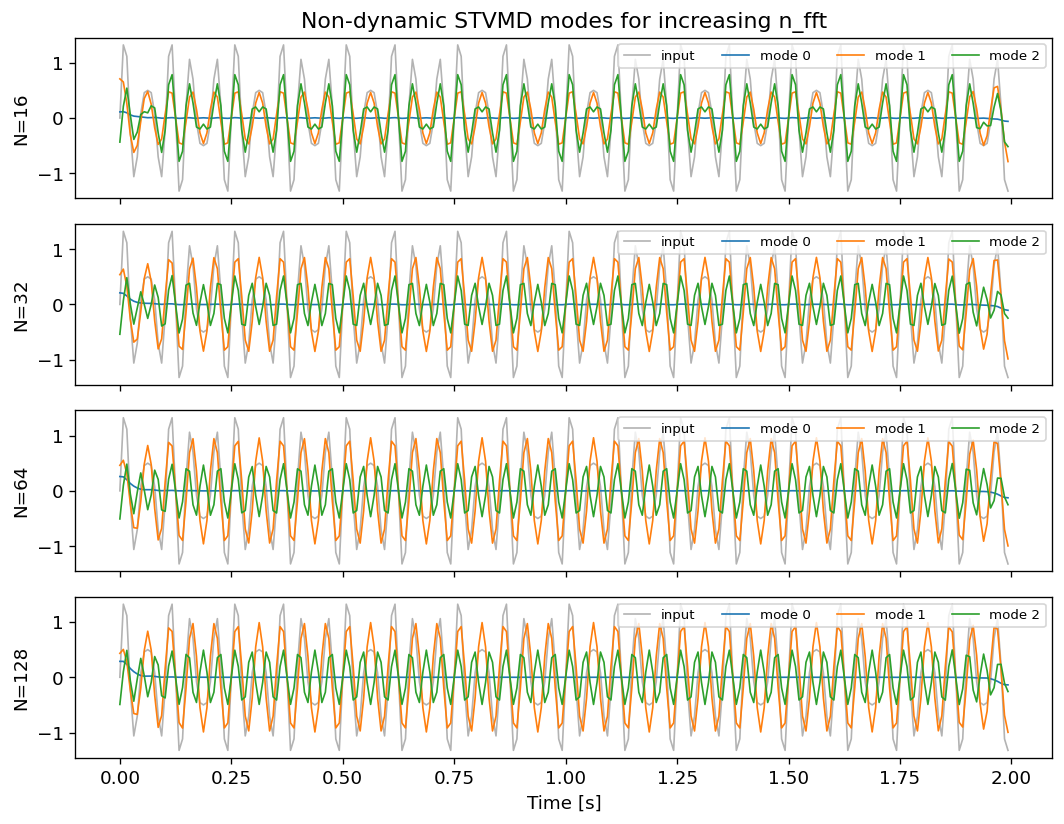

In [6]:
nfft_list = [16, 32, 64, 128]
fig, axs = plt.subplots(len(nfft_list), 1, figsize=(9, 7), sharex=True)
for ax, nfft in zip(axs, nfft_list):
    decomp = STVMD(
        K=3,
        alpha=50.0,
        n_fft=nfft,
        tau=1e-5,
        tol=1e-9,
        max_iter=400,
        dynamic=False,
        window="hamming",
    )
    modes = decomp.fit_transform(signal)
    ax.plot(t, signal, color="0.7", lw=1.0, label="input")
    for k in range(modes.shape[0]):
        ax.plot(t, modes[k], lw=1.0, label=f"mode {k}")
    ax.set_ylabel(f"N={nfft}")
    ax.legend(loc="upper right", ncol=4, fontsize=8)
axs[-1].set_xlabel("Time [s]")
axs[0].set_title("Non-dynamic STVMD modes for increasing n_fft")
plt.tight_layout()
plt.show()

## 2. Non-stationary frequency-hopping signal

Dynamic STVMD tracks time-varying centre frequencies more faithfully than fixed-frequency methods.


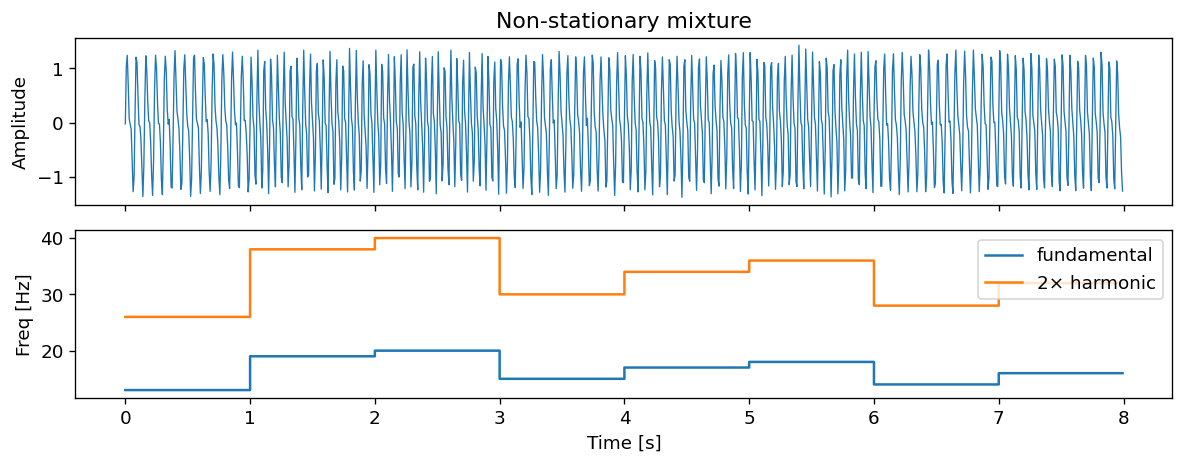

In [7]:
N = 1024
fs = 128.0
t = np.arange(N) / fs
rng = np.random.default_rng(7)
seq = rng.permutation(np.arange(8))


def omega_t(tt):
    return seq[np.floor(tt).astype(int) % 8] + 13.0


x1 = np.sin(2 * np.pi * omega_t(t) * t)
x2 = 0.5 * np.sin(2 * np.pi * (2 * omega_t(t)) * t)
signal_ns = x1 + x2 + 0.05 * rng.standard_normal(N)

fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axs[0].plot(t, signal_ns, lw=0.8)
axs[0].set_ylabel("Amplitude")
axs[0].set_title("Non-stationary mixture")
axs[1].step(t, omega_t(t), where="post", label="fundamental")
axs[1].step(t, 2 * omega_t(t), where="post", label="2× harmonic")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Freq [Hz]")
axs[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

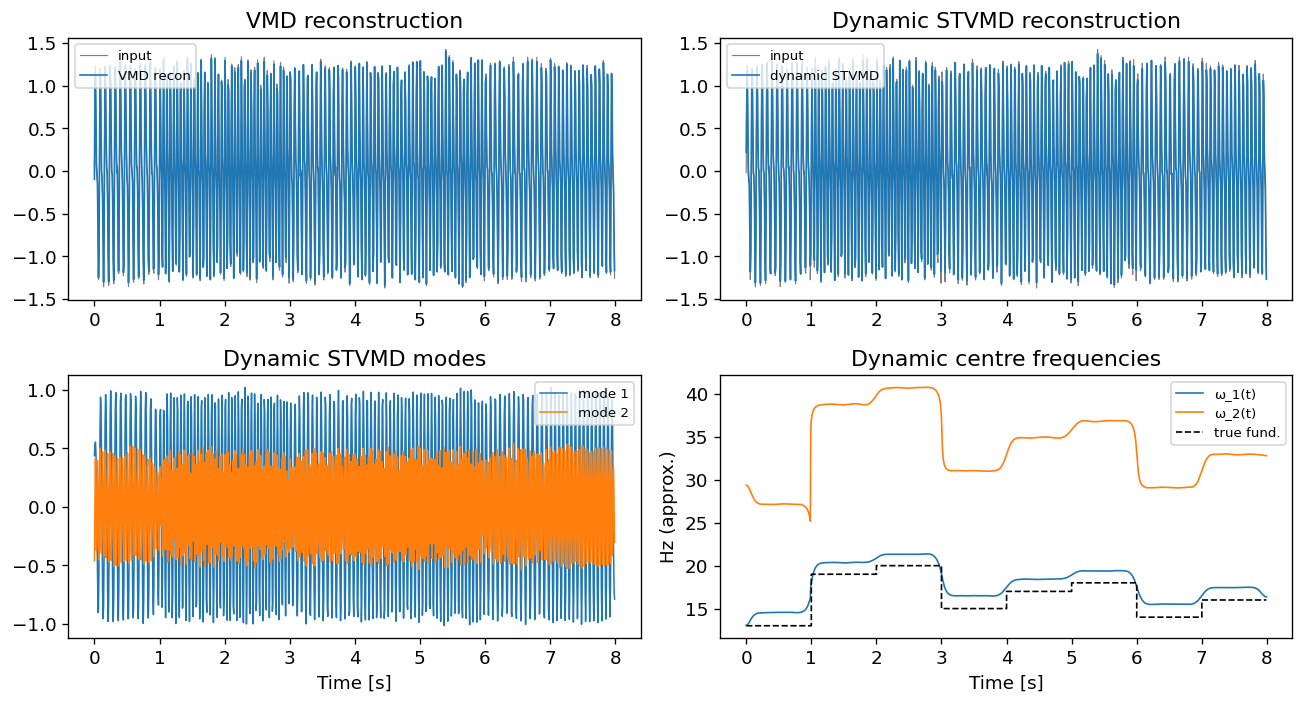

VMD        relative recon. error = 2.9372e-02
STVMD-ND   relative recon. error = 1.0793e-01
STVMD-D    relative recon. error = 4.1233e-02


In [8]:
n_fft = 64
K = 3
alpha = 50.0

vmd = VMD(K=K, alpha=alpha, tau=1e-5, tol=1e-9, max_iter=500)
imf_vmd_ns = vmd.fit_transform(signal_ns)

st_nd = STVMD(
    K=K,
    alpha=alpha,
    n_fft=n_fft,
    tau=1e-5,
    tol=1e-9,
    max_iter=500,
    dynamic=False,
    window="hamming",
)
imf_nd_ns, _, omega_nd_ns = st_nd.fit_transform(signal_ns, return_all=True)

st_d = STVMD(
    K=K,
    alpha=alpha,
    n_fft=n_fft,
    tau=1e-5,
    tol=1e-9,
    max_iter=500,
    dynamic=True,
    window="hamming",
)
imf_d_ns, u_hat_d, omega_d_ns = st_d.fit_transform(signal_ns, return_all=True)

# Map normalized STFT frequencies roughly to Hz: bin / F * (fs/2) is approximate;
# author code reports omega in [0, 1] over rFFT bins. Convert by * (fs / 2).
omega_hz = omega_d_ns * (fs / 2.0)

fig, axs = plt.subplots(2, 2, figsize=(11, 6))
axs[0, 0].plot(t, signal_ns, color="0.5", lw=0.7, label="input")
axs[0, 0].plot(t, imf_vmd_ns.sum(0), lw=1.0, label="VMD recon")
axs[0, 0].set_title("VMD reconstruction")
axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(t, signal_ns, color="0.5", lw=0.7, label="input")
axs[0, 1].plot(t, imf_d_ns.sum(0), lw=1.0, label="dynamic STVMD")
axs[0, 1].set_title("Dynamic STVMD reconstruction")
axs[0, 1].legend(fontsize=8)

for k in range(1, K):
    axs[1, 0].plot(t, imf_d_ns[k], lw=0.9, label=f"mode {k}")
axs[1, 0].set_title("Dynamic STVMD modes")
axs[1, 0].legend(fontsize=8)
axs[1, 0].set_xlabel("Time [s]")

# Centre-frequency tracks (skip near-DC mode 0)
frame_t = np.linspace(0, t[-1], omega_hz.shape[1])
for k in range(1, K):
    axs[1, 1].plot(frame_t, omega_hz[k], lw=1.0, label=f"ω_{k}(t)")
axs[1, 1].step(
    t, omega_t(t), where="post", color="k", ls="--", lw=1.0, label="true fund."
)
axs[1, 1].set_title("Dynamic centre frequencies")
axs[1, 1].set_xlabel("Time [s]")
axs[1, 1].set_ylabel("Hz (approx.)")
axs[1, 1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for name, modes in [
    ("VMD", imf_vmd_ns),
    ("STVMD-ND", imf_nd_ns),
    ("STVMD-D", imf_d_ns),
]:
    re = np.linalg.norm(modes.sum(0) - signal_ns) / np.linalg.norm(signal_ns)
    print(f"{name:10s} relative recon. error = {re:.4e}")

## 3. Multivariate (two-channel) example

STVMD inherits the MVMD idea of shared centre frequencies across channels within each frame.


modes shape: (4, 2, 256)


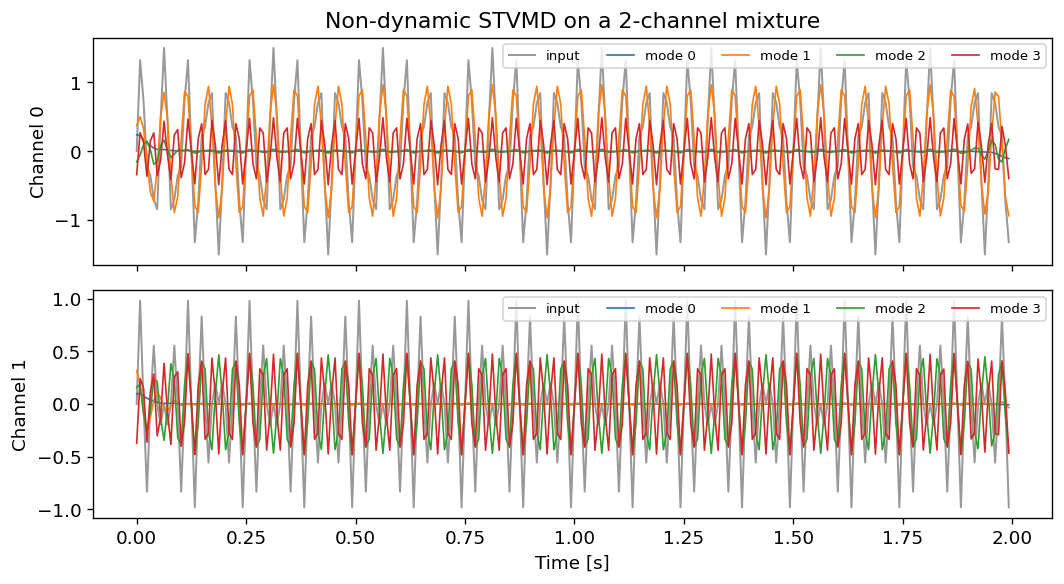

In [9]:
N = 256
fs = 128.0
t = np.arange(N) / fs
s1 = np.sin(2 * np.pi * 20 * t) + 0.5 * np.sin(2 * np.pi * 36 * t)
s2 = 0.5 * np.sin(2 * np.pi * 28 * t) + 0.5 * np.sin(2 * np.pi * 36 * t)
multi = np.vstack([s1, s2])

decomp = STVMD(
    K=4,
    alpha=50.0,
    n_fft=64,
    tau=1e-5,
    tol=1e-9,
    max_iter=400,
    dynamic=False,
    window="hamming",
)
modes = decomp.fit_transform(multi)  # shape (K, C, T)
print("modes shape:", modes.shape)

fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for c in range(2):
    axs[c].plot(t, multi[c], color="0.6", lw=1.2, label="input")
    for k in range(modes.shape[0]):
        axs[c].plot(t, modes[k, c], lw=1.0, label=f"mode {k}")
    axs[c].set_ylabel(f"Channel {c}")
    axs[c].legend(loc="upper right", ncol=5, fontsize=8)
axs[-1].set_xlabel("Time [s]")
axs[0].set_title("Non-dynamic STVMD on a 2-channel mixture")
plt.tight_layout()
plt.show()

## Quick API reminder

`python
from pysdkit import STVMD, stvmd

st = STVMD(K=3, alpha=50, n_fft=64, dynamic=True)
modes = st.fit_transform(signal)                 # (K, T)
modes, u_hat, omega = st.fit_transform(signal, return_all=True)

# functional shortcut
modes = stvmd(signal, K=3, alpha=50, n_fft=64, dynamic=False)
`
